<a href="https://colab.research.google.com/github/EyadMHussien/clustering_comparative_analysis/blob/main/clustering_comparative_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 1. Load the dataset

In [ ]:
import pandas as pd

# Load the dataset
df = pd.read_csv('Wholesale customers data.csv')

print("Dataset loaded successfully.")

Dataset loaded successfully.


### 2. Inspect the dataset structure

This step involves checking the number of samples (rows), number of features (columns), and data types of each column to get an overview of the dataset.

In [ ]:
# Display the first 5 rows of the DataFrame
display(df.head())

# Get the number of samples and features
print(f"Number of samples: {df.shape[0]}")
print(f"Number of features: {df.shape[1]}")

# Get information about the dataset, including data types and non-null values
df.info()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


Number of samples: 440
Number of features: 8
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    int64
 1   Region            440 non-null    int64
 2   Fresh             440 non-null    int64
 3   Milk              440 non-null    int64
 4   Grocery           440 non-null    int64
 5   Frozen            440 non-null    int64
 6   Detergents_Paper  440 non-null    int64
 7   Delicassen        440 non-null    int64
dtypes: int64(8)
memory usage: 27.6 KB


### 3. Check for missing values

Missing values can affect the performance of machine learning models. This step identifies if there are any missing entries in the dataset and, if so, how many.

In [ ]:
# Check for missing values in each column
missing_values = df.isnull().sum()
print("Missing values per column:")
print(missing_values)

# If there are missing values, you can choose to:
# 1. Drop rows with missing values: df.dropna(inplace=True)
# 2. Impute missing values (e.g., with mean, median, or mode):
#    For numerical columns: df['column_name'].fillna(df['column_name'].mean(), inplace=True)
#    For categorical columns: df['column_name'].fillna(df['column_name'].mode()[0], inplace=True)

# In this dataset, there appear to be no missing values, so no imputation or dropping is needed.

Missing values per column:
Channel             0
Region              0
Fresh               0
Milk                0
Grocery             0
Frozen              0
Detergents_Paper    0
Delicassen          0
dtype: int64


### 4. Remove duplicate observations

Duplicate rows can skew analysis and model training. This step identifies and removes any exact duplicate rows from the dataset.

In [ ]:
print(f"Number of rows before removing duplicates: {df.shape[0]}")

# Remove duplicate rows
df.drop_duplicates(inplace=True)

print(f"Number of rows after removing duplicates: {df.shape[0]}")

Number of rows before removing duplicates: 440
Number of rows after removing duplicates: 440


### 5. Apply feature scaling

Feature scaling is important when features have different ranges, as it prevents features with larger values from dominating the learning process. Standardization (Z-score normalization) is a common technique that transforms data to have a mean of 0 and a standard deviation of 1. Min-Max normalization scales features to a fixed range, usually 0 to 1.

In [ ]:
from sklearn.preprocessing import StandardScaler

# Identify numerical features for scaling. Exclude 'Channel' and 'Region' if they are categorical identifiers.
# Assuming 'Channel' and 'Region' are categorical and will be handled separately if needed for modeling,
# or are already encoded if treated as numerical for now.
# Let's scale all columns except 'Channel' and 'Region' for now, if they are not to be scaled.
# For this dataset, all columns seem to be numerical and represent quantities, so we can scale them all.

numerical_cols = df.columns.tolist()
# If 'Channel' or 'Region' were actual categorical features that needed one-hot encoding,
# they would be handled before scaling numerical features.

# Initialize the StandardScaler
scaler = StandardScaler()

# Apply standardization to the DataFrame
df_scaled = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)

print("Dataset after feature scaling (Standardization):")
display(df_scaled.head())

Dataset after feature scaling (Standardization):


,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,1.448652,0.590668,0.052933,0.523568,-0.041115,-0.589367,-0.043569,-0.066339
1,1.448652,0.590668,-0.391302,0.544458,0.170318,-0.270136,0.086407,0.089151
2,1.448652,0.590668,-0.447029,0.408538,-0.028157,-0.137536,0.133232,2.243293
3,-0.690297,0.590668,0.100111,-0.624020,-0.392977,0.687144,-0.498588,0.093411
4,1.448652,0.590668,0.840239,-0.052396,-0.079356,0.173859,-0.231918,1.299347


### 6. Detect potential outliers using visualization methods

Outliers are data points that significantly differ from other observations. They can be detected using statistical methods or visualization techniques like box plots. Here, we'll use box plots to visualize the distribution of each feature and identify potential outliers.

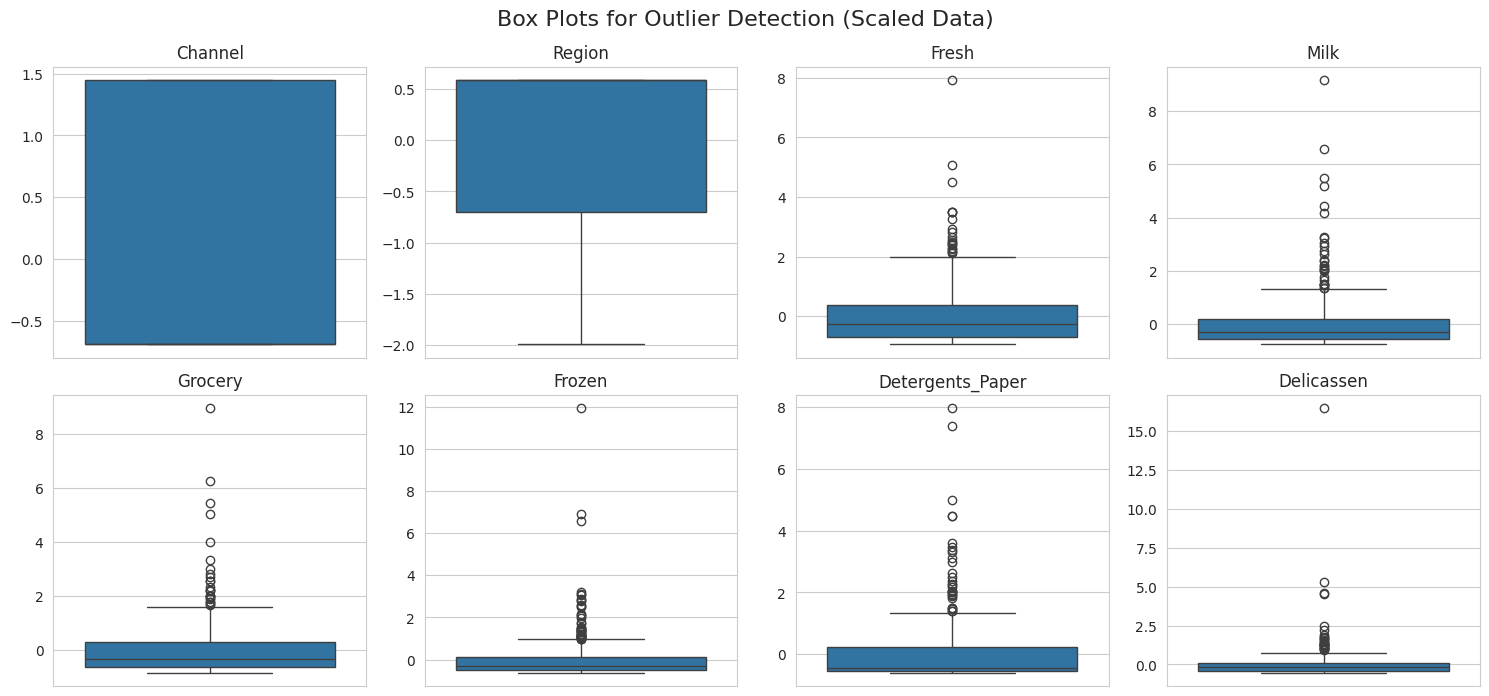

Potential outliers are visible as points outside the whiskers of the box plots.
Further investigation and domain knowledge would be needed to decide whether to remove or transform them.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the aesthetic style of the plots
sns.set_style("whitegrid")

# Create box plots for each numerical feature to visualize outliers
plt.figure(figsize=(15, 10))
for i, column in enumerate(df_scaled.columns):
    plt.subplot(3, 4, i + 1) # Adjust subplot grid as per number of columns
    sns.boxplot(y=df_scaled[column])
    plt.title(column)
    plt.ylabel('') # Remove y-label to avoid clutter
plt.tight_layout()
plt.suptitle('Box Plots for Outlier Detection (Scaled Data)', y=1.02, fontsize=16)
plt.show()

print("Potential outliers are visible as points outside the whiskers of the box plots.")
print("Further investigation and domain knowledge would be needed to decide whether to remove or transform them.")

### 7. Apply dimensionality reduction using Principal Component Analysis (PCA)

PCA is a technique used to reduce the dimensionality of a dataset while retaining as much variance as possible. It is particularly useful when dealing with datasets that have a large number of correlated features. For this dataset, with 8 features, PCA might not be strictly necessary, but it's a good demonstration of the technique. We will keep components that explain a significant portion of the variance (e.g., 95%).

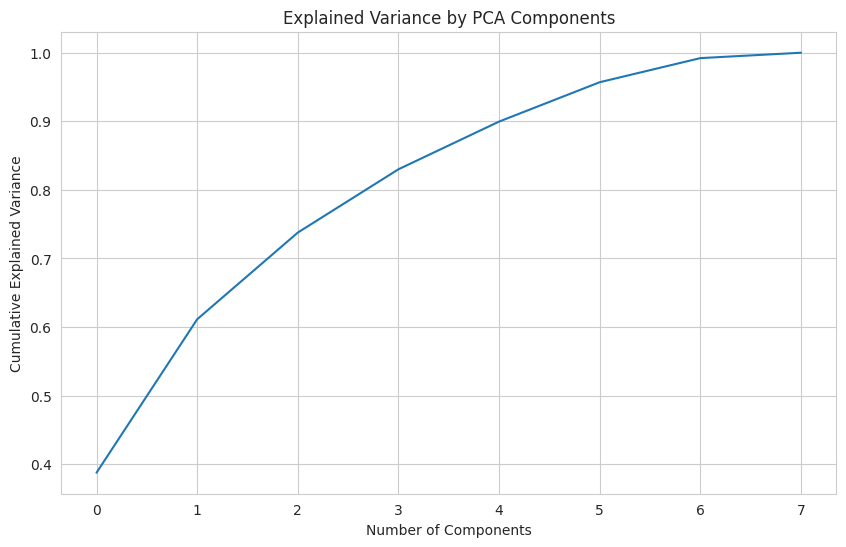

Number of components to explain 95% of variance: 6
Dataset after applying PCA:


,PC_1,PC_2,PC_3,PC_4,PC_5,PC_6
0,0.843939,-0.515351,0.767632,0.044215,-0.446234,0.939441
1,1.062676,-0.484601,0.672975,-0.401372,-0.130458,0.867227
2,1.269141,0.682055,0.664095,-1.634953,-1.193813,1.078442
3,-1.056782,0.610821,0.505654,-0.196005,0.457855,-0.116959
4,0.634030,0.974199,0.771209,-0.186374,-0.813877,1.505372


In [ ]:
from sklearn.decomposition import PCA
import numpy as np

# Initialize PCA
pca = PCA()

# Fit PCA on the scaled data
pca.fit(df_scaled)

# Plot the explained variance ratio
plt.figure(figsize=(10, 6))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance by PCA Components')
plt.grid(True)
plt.show()

# Determine the number of components to retain (e.g., 95% variance)
n_components = np.argmax(np.cumsum(pca.explained_variance_ratio_) >= 0.95) + 1
print(f"Number of components to explain 95% of variance: {n_components}")

# Apply PCA with the chosen number of components
pca = PCA(n_components=n_components)
df_pca = pd.DataFrame(pca.fit_transform(df_scaled), columns=[f'PC_{i+1}' for i in range(n_components)])

print("Dataset after applying PCA:")
display(df_pca.head())

### 8. Distribution plots for numerical features

Histograms and KDE (Kernel Density Estimate) plots are useful for visualizing the distribution of individual numerical features. This helps in understanding the shape of the data, identifying skewness, and detecting modes.

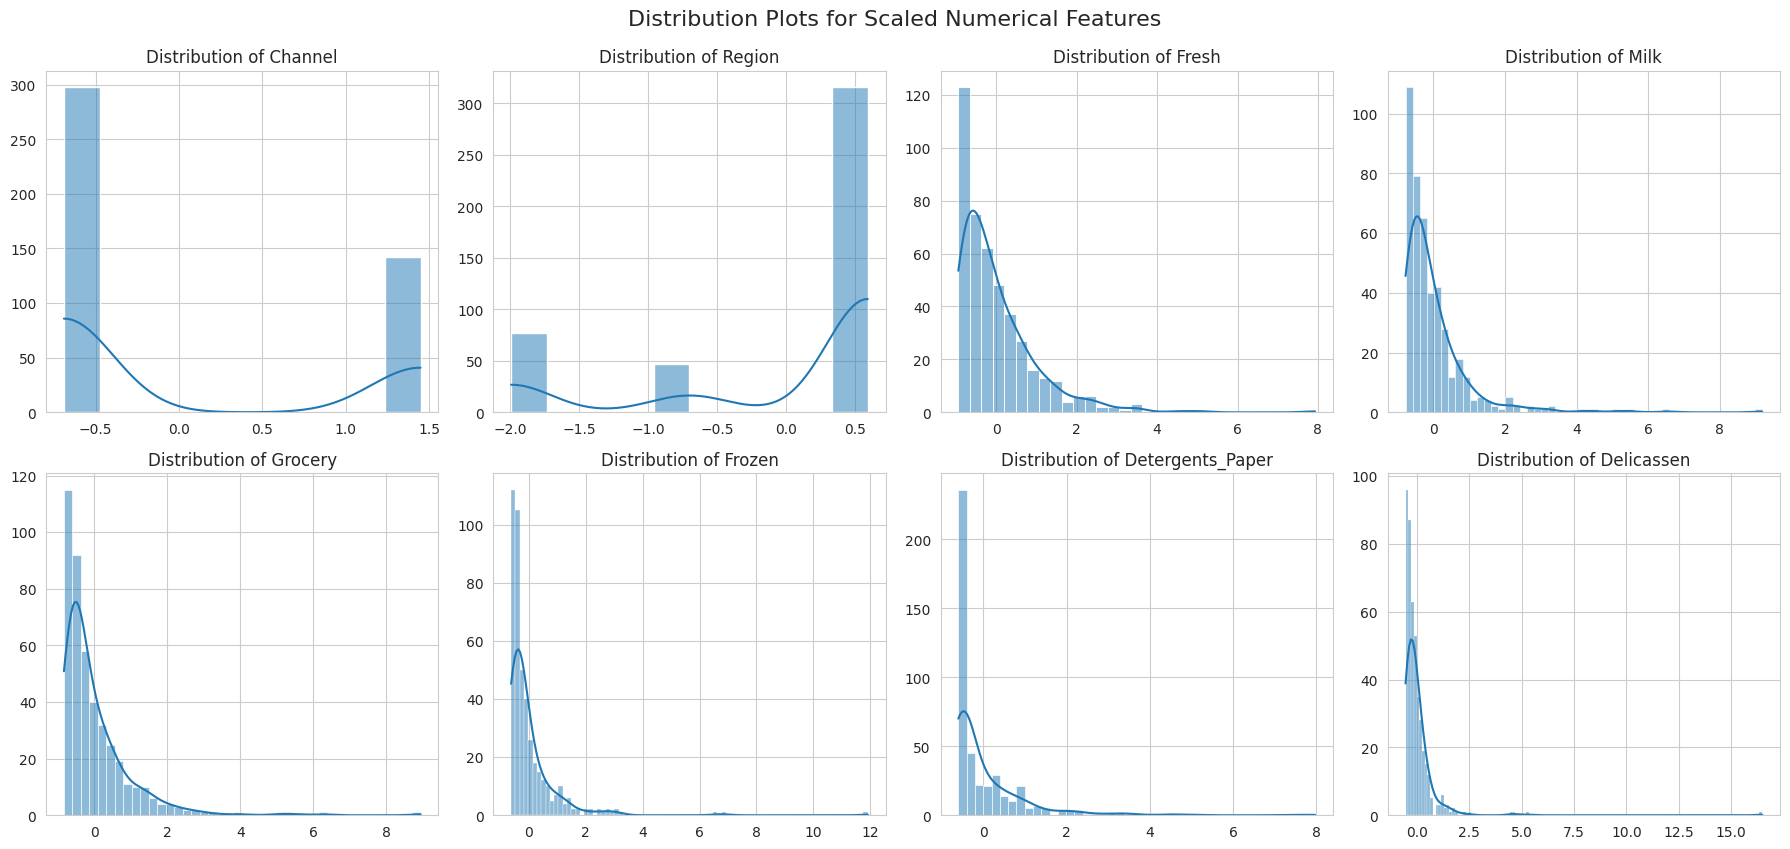

These plots show the distribution of each scaled feature. Skewness and potential multi-modality can be observed.


In [ ]:
plt.figure(figsize=(18, 12))
for i, column in enumerate(df_scaled.columns):
    plt.subplot(3, 4, i + 1) # Adjust subplot grid as per number of columns
    sns.histplot(df_scaled[column], kde=True)
    plt.title(f'Distribution of {column}')
    plt.xlabel('')
    plt.ylabel('')
plt.tight_layout()
plt.suptitle('Distribution Plots for Scaled Numerical Features', y=1.02, fontsize=16)
plt.show()

print("These plots show the distribution of each scaled feature. Skewness and potential multi-modality can be observed.")

### 9. Correlation heatmap to analyze relationships between variables

A correlation heatmap visualizes the correlation matrix of numerical features. It helps in identifying features that are highly correlated with each other, which can be useful for feature selection or understanding multicollinearity.

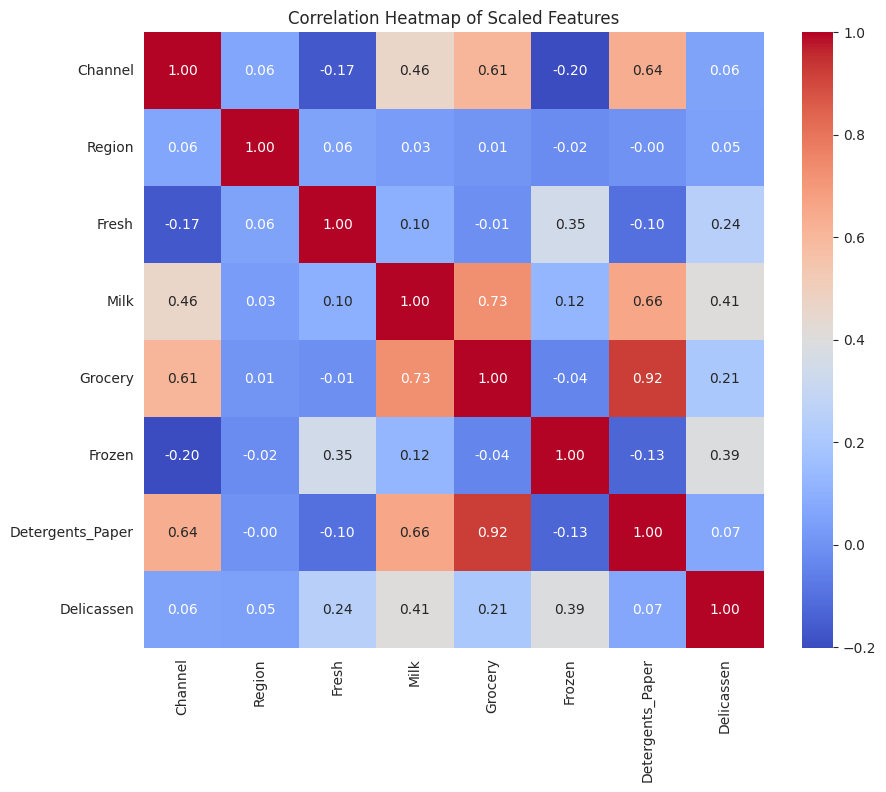

The heatmap shows the correlation coefficients between each pair of scaled features. Values close to 1 or -1 indicate strong positive or negative correlation, respectively.


In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(df_scaled.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Scaled Features')
plt.show()

print("The heatmap shows the correlation coefficients between each pair of scaled features. Values close to 1 or -1 indicate strong positive or negative correlation, respectively.")

### 10. Pairwise feature plots to observe feature interactions

Pair plots (or scatter plot matrices) display scatter plots for each pair of features, and often histograms or KDE plots for univariate distributions. This is excellent for observing relationships and distributions across multiple features simultaneously.

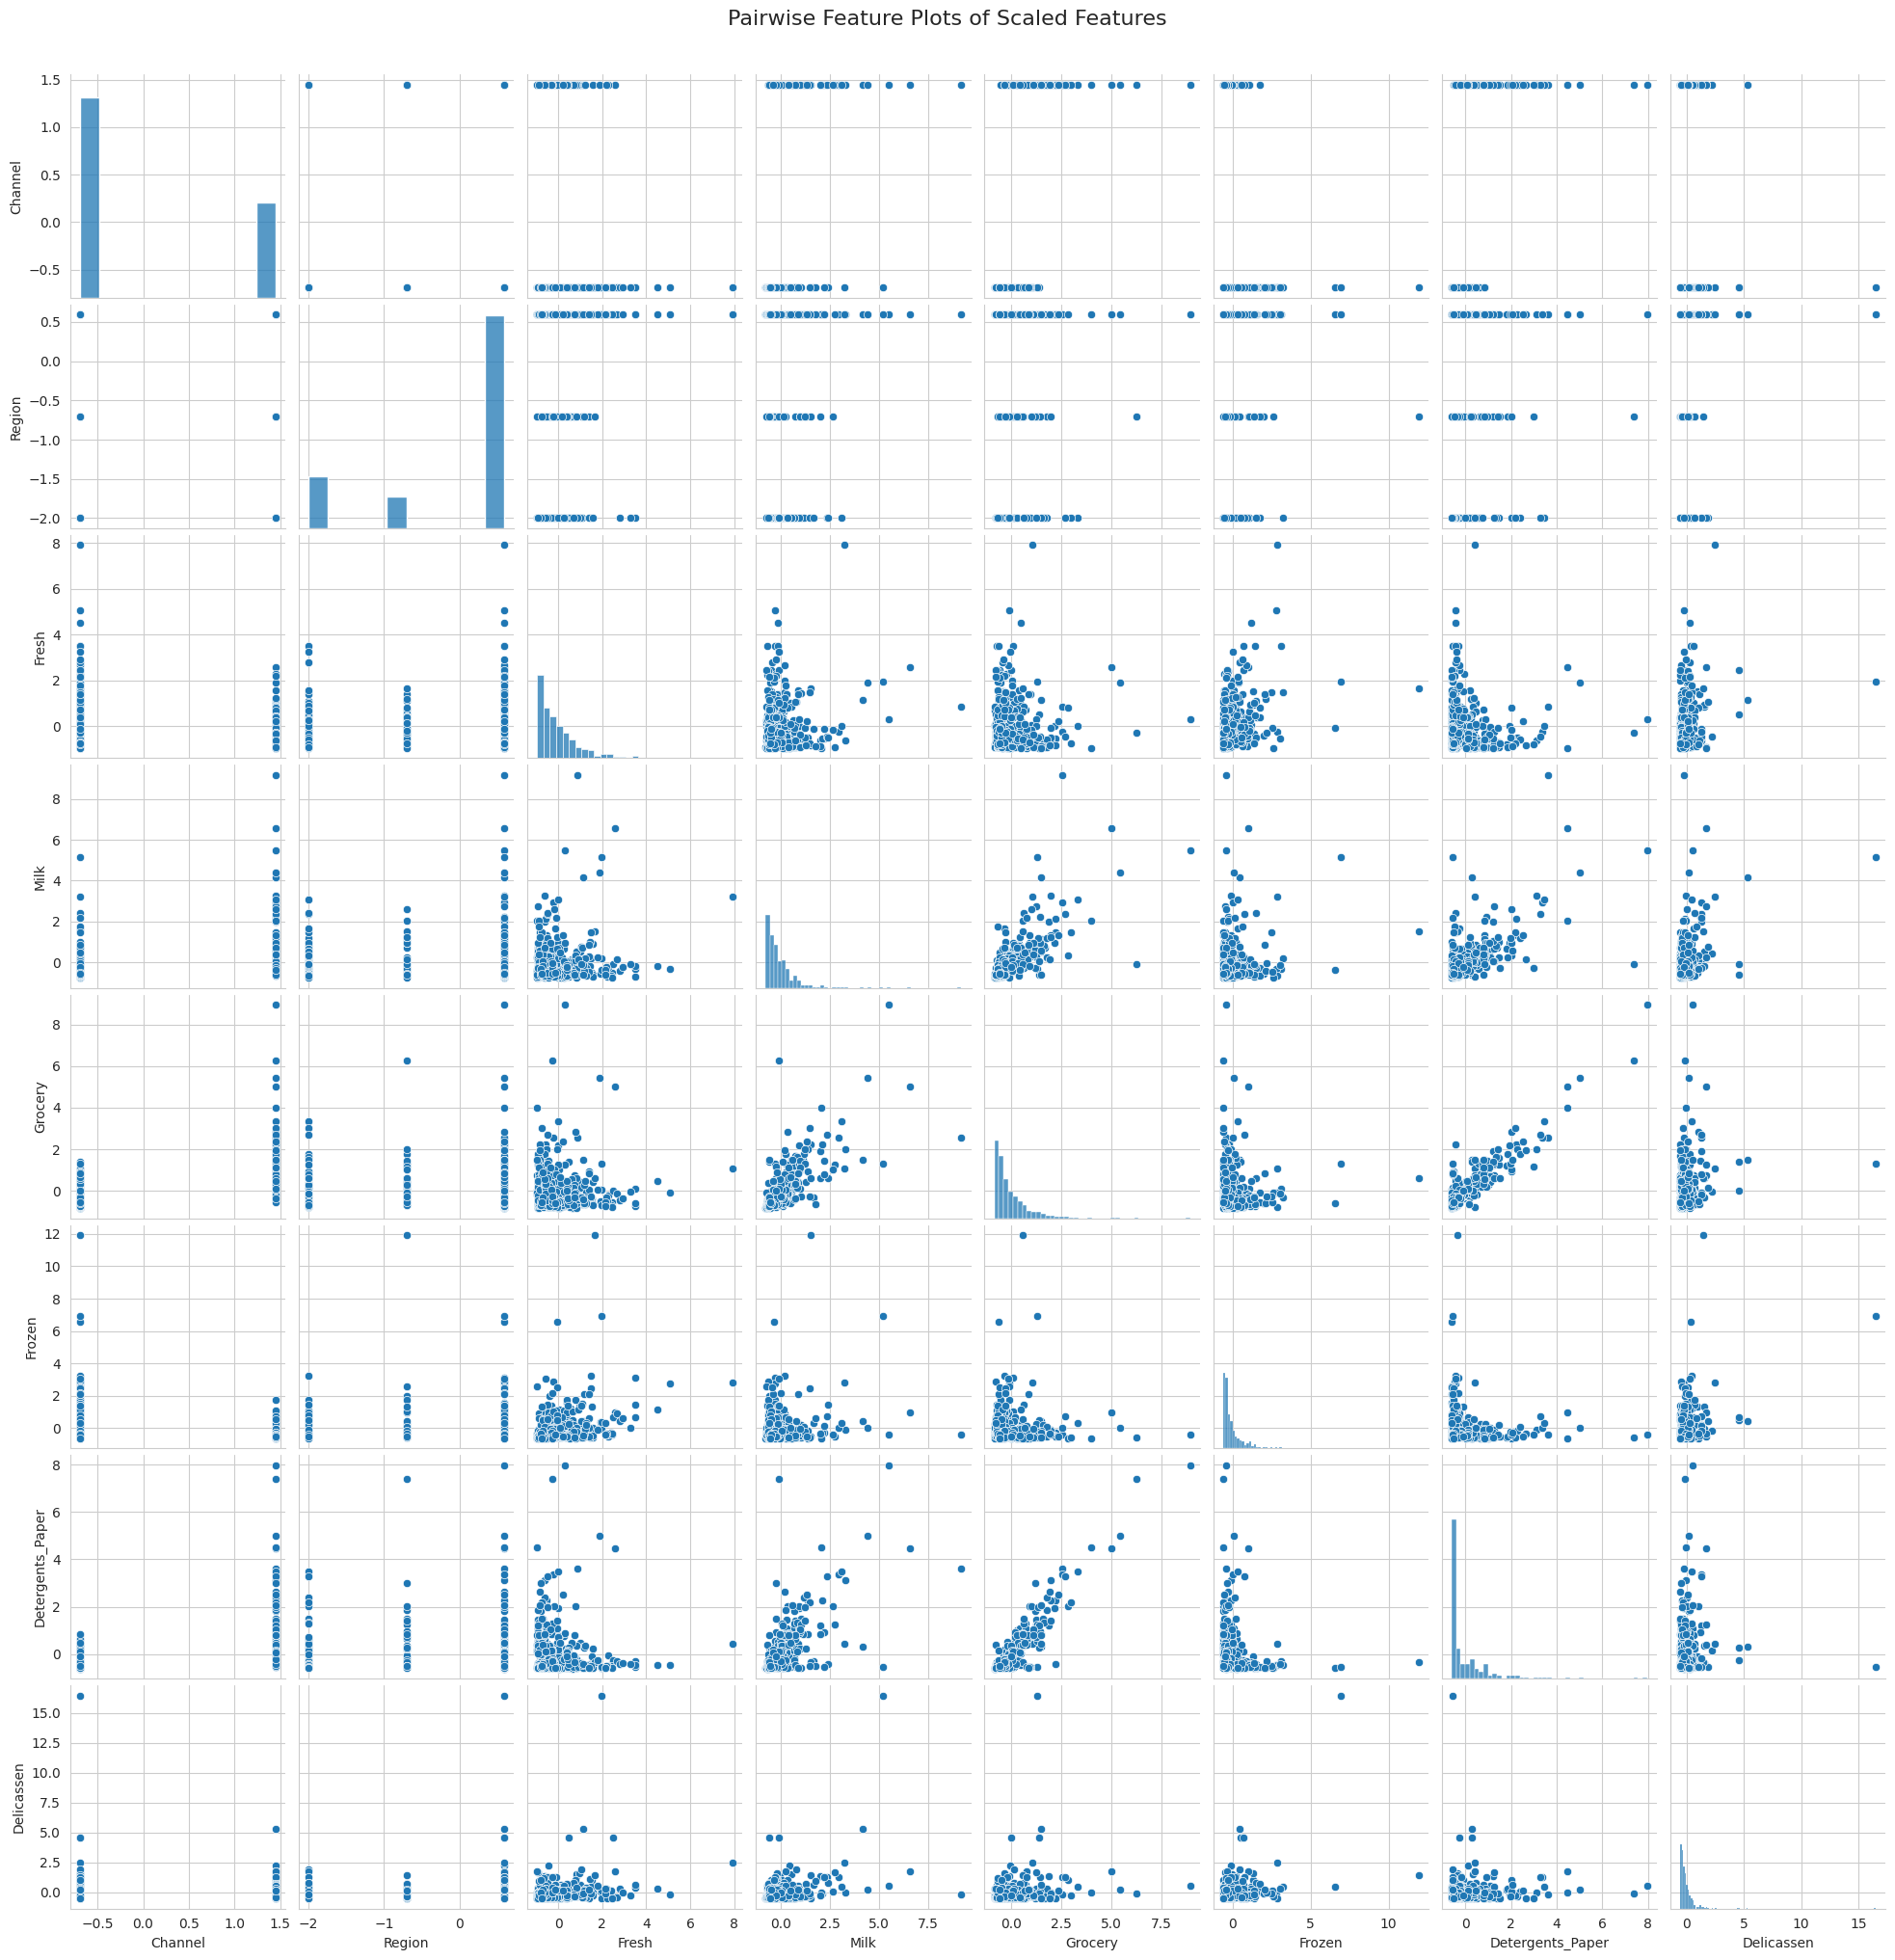

Pair plots show scatter plots for each feature pair and distributions for single features, allowing for observation of relationships and potential clusters.


In [ ]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

# For better readability, we might not want to plot all features if there are too many.
# Let's plot a subset or consider using 'kind="kde"' for smoother representation.
# For this dataset, with 8 features, a full pairplot is manageable.

sns.pairplot(df_scaled)
plt.suptitle('Pairwise Feature Plots of Scaled Features', y=1.02, fontsize=16)
plt.show()

print("Pair plots show scatter plots for each feature pair and distributions for single features, allowing for observation of relationships and potential clusters.")

### 11. Scatter plots between selected feature pairs

While pair plots give a comprehensive overview, individual scatter plots allow for more focused investigation of specific feature interactions. We'll pick a few interesting pairs based on the correlation heatmap or general domain knowledge.

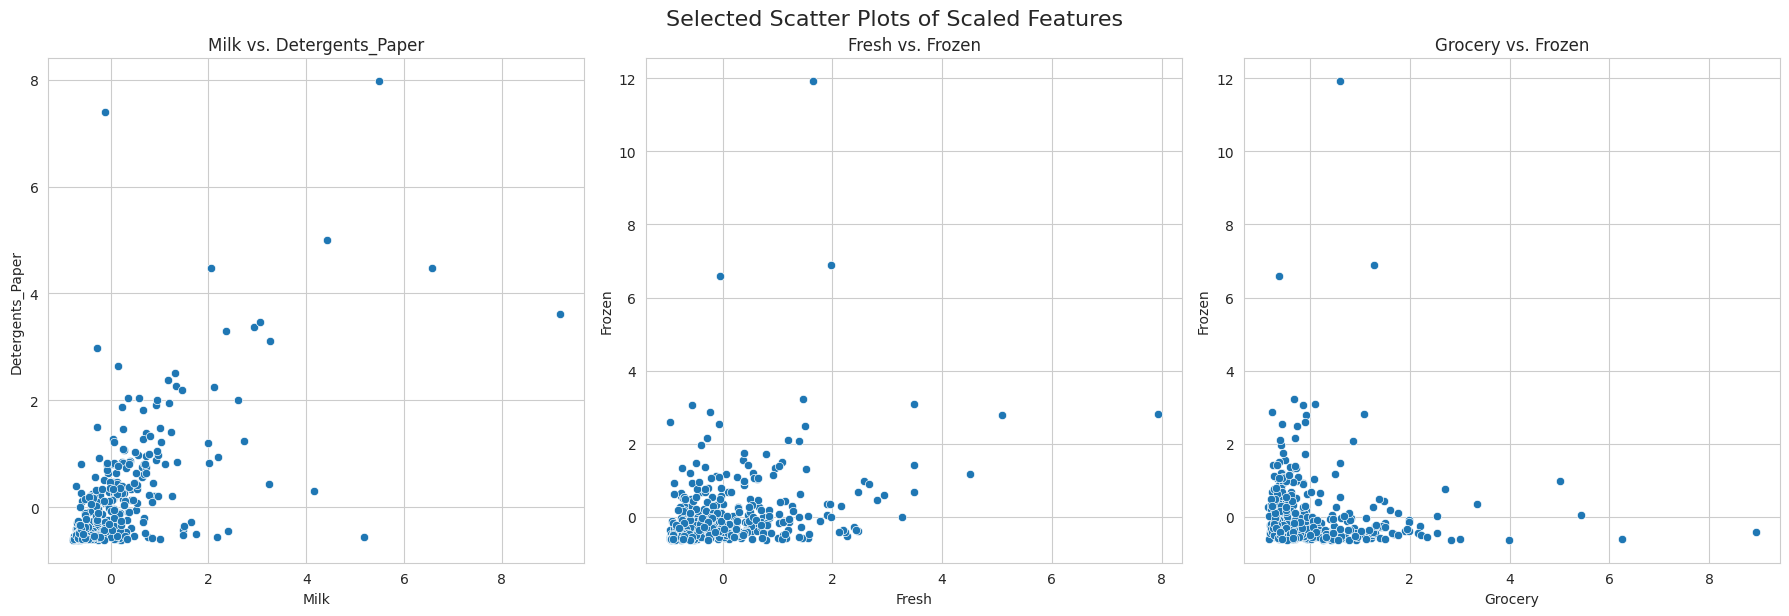

These scatter plots highlight specific relationships between chosen pairs of features, which can reveal trends or clusters.


In [ ]:
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
sns.scatterplot(x=df_scaled['Milk'], y=df_scaled['Detergents_Paper'])
plt.title('Milk vs. Detergents_Paper')

plt.subplot(1, 3, 2)
sns.scatterplot(x=df_scaled['Fresh'], y=df_scaled['Frozen'])
plt.title('Fresh vs. Frozen')

plt.subplot(1, 3, 3)
sns.scatterplot(x=df_scaled['Grocery'], y=df_scaled['Frozen'])
plt.title('Grocery vs. Frozen')

plt.tight_layout()
plt.suptitle('Selected Scatter Plots of Scaled Features', y=1.02, fontsize=16)
plt.show()

print("These scatter plots highlight specific relationships between chosen pairs of features, which can reveal trends or clusters.")

### 12. Two-dimensional visualization using PCA projection

If PCA was applied, visualizing the data in the top 2 principal components can reveal underlying structure, clusters, or anomalies in a reduced dimensionality space. This is especially useful when the original dataset has many features.

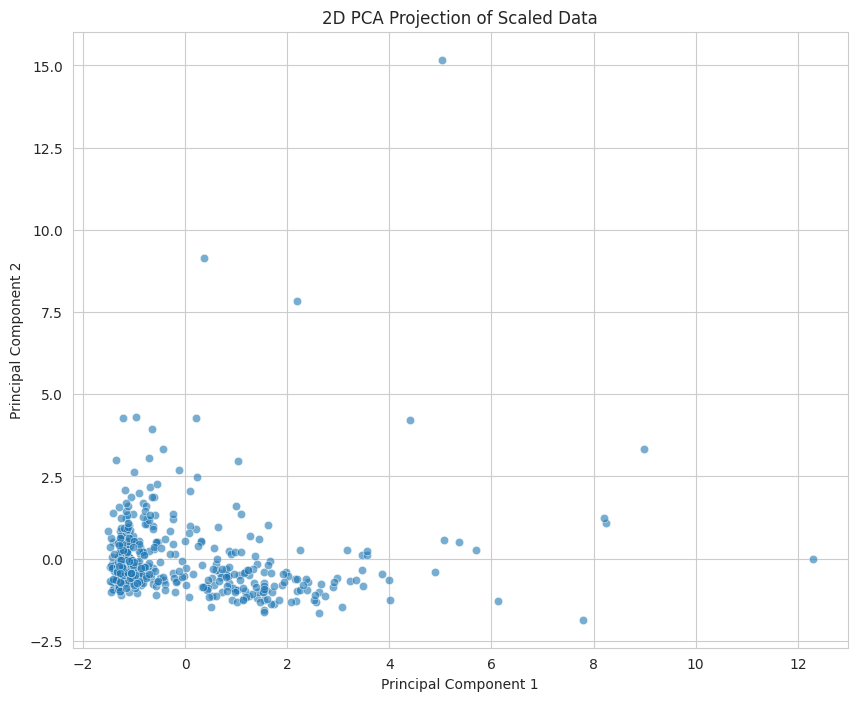

This 2D plot using the first two principal components helps visualize the data's structure in a lower-dimensional space, potentially revealing clusters or patterns that were harder to see in the original high-dimensional data.


In [ ]:
if df_pca.shape[1] >= 2:
    plt.figure(figsize=(10, 8))
    sns.scatterplot(x='PC_1', y='PC_2', data=df_pca, alpha=0.6)
    plt.title('2D PCA Projection of Scaled Data')
    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    plt.grid(True)
    plt.show()
else:
    print("Cannot perform 2D PCA projection as there are fewer than 2 principal components retained.")

print("This 2D plot using the first two principal components helps visualize the data's structure in a lower-dimensional space, potentially revealing clusters or patterns that were harder to see in the original high-dimensional data.")

### 13. Apply t-SNE to obtain a non-linear two-dimensional visualization of the dataset

t-SNE (t-distributed Stochastic Neighbor Embedding) is a non-linear dimensionality reduction technique particularly well-suited for visualizing high-dimensional datasets. It tries to preserve local structures and is often effective at revealing clusters in the data. Since t-SNE is computationally intensive, it's generally applied to data that has already undergone some initial dimensionality reduction (like PCA) or to smaller datasets.

Applying t-SNE, this might take a moment...
t-SNE completed in 2.86 seconds.


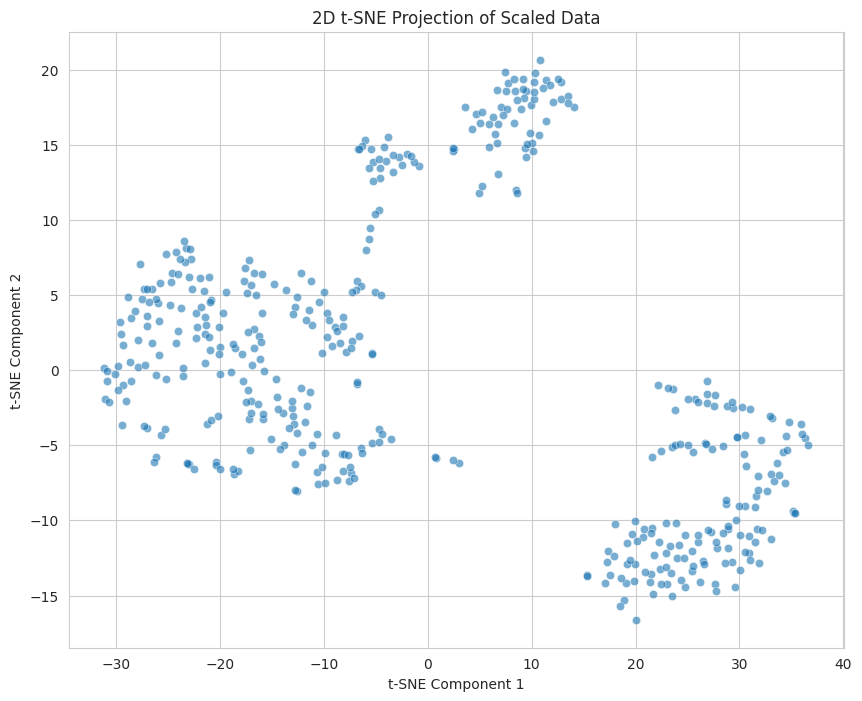

The t-SNE plot provides a non-linear, 2D representation of the data, often revealing more intricate clustering patterns than PCA.


In [ ]:
from sklearn.manifold import TSNE
import time

# Apply t-SNE to the scaled data (or PCA-reduced data for larger datasets)
# For this dataset size, applying directly to df_scaled is acceptable.

print("Applying t-SNE, this might take a moment...")
start_time = time.time()
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
df_tsne = tsne.fit_transform(df_scaled)
end_time = time.time()
print(f"t-SNE completed in {end_time - start_time:.2f} seconds.")

df_tsne_df = pd.DataFrame(data=df_tsne, columns=['TSNE_1', 'TSNE_2'])

plt.figure(figsize=(10, 8))
sns.scatterplot(x='TSNE_1', y='TSNE_2', data=df_tsne_df, alpha=0.6)
plt.title('2D t-SNE Projection of Scaled Data')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.grid(True)
plt.show()

print("The t-SNE plot provides a non-linear, 2D representation of the data, often revealing more intricate clustering patterns than PCA.")

### 14. Optimal Number of Clusters (Elbow Method)

The Elbow Method is a heuristic used to determine the optimal number of clusters for a given dataset. It plots the within-cluster sum of squares (WCSS) against the number of clusters (K). The 'elbow point' in the plot, where the rate of decrease in WCSS sharply changes, is often considered the optimal K.

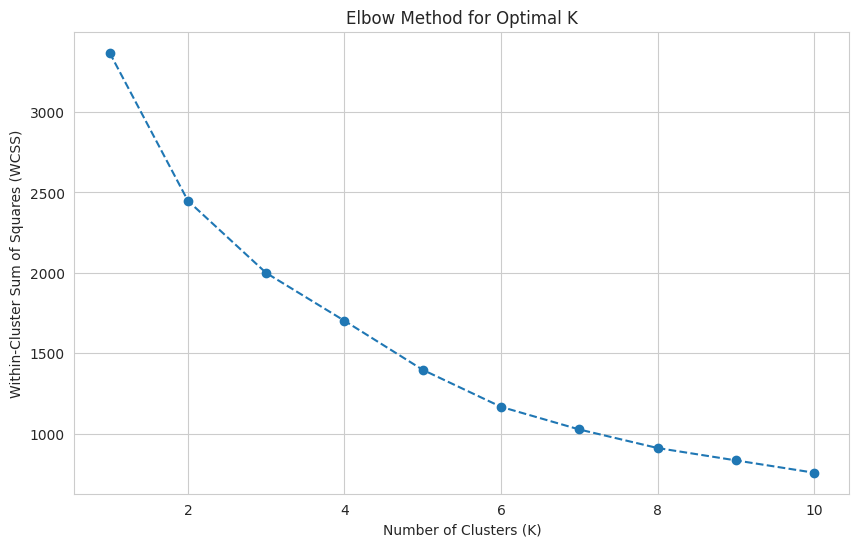

The Elbow curve helps visually identify the 'optimal' number of clusters where the rate of decrease in WCSS begins to slow down significantly.


In [ ]:
from sklearn.cluster import KMeans

# Using the PCA-reduced data for clustering, or scaled data if PCA resulted in too few components
data_for_clustering = df_pca if df_pca.shape[1] >= 2 else df_scaled

wcss = []
max_k = 10 # Define a reasonable range for K

for i in range(1, max_k + 1):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(data_for_clustering)
    wcss.append(kmeans.inertia_)

# Plot the Elbow curve
plt.figure(figsize=(10, 6))
plt.plot(range(1, max_k + 1), wcss, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.grid(True)
plt.show()

print("The Elbow curve helps visually identify the 'optimal' number of clusters where the rate of decrease in WCSS begins to slow down significantly.")

### 15. K-Means Clustering

K-Means is a popular unsupervised learning algorithm used for clustering. It aims to partition `n` observations into `k` clusters in which each observation belongs to the cluster with the nearest mean (cluster centroid), serving as a prototype of the cluster. We will apply it with K=2, 3, and 4.

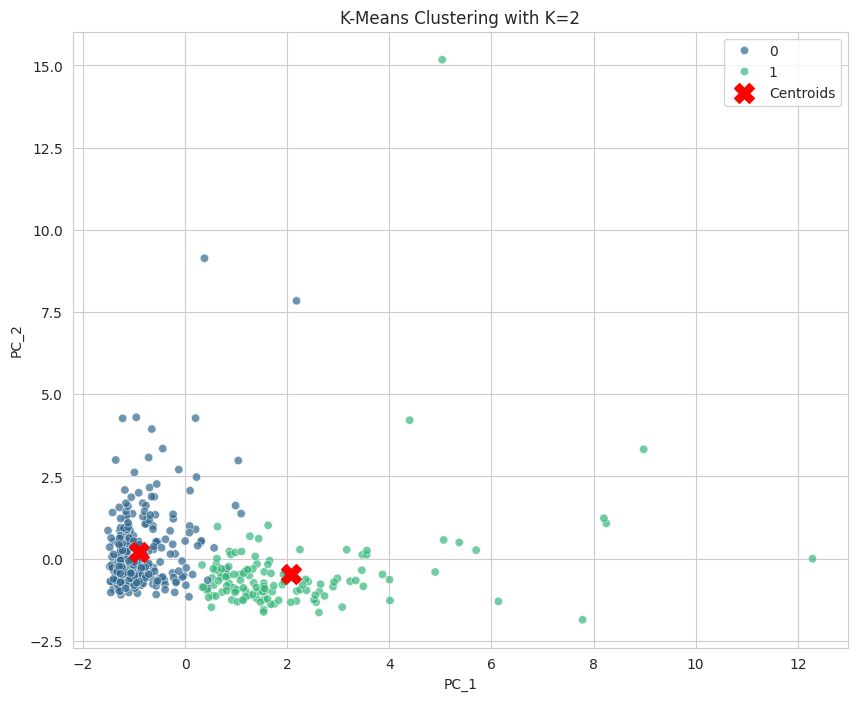

K-Means clustering with K=2 performed. Centroids and cluster assignments are visualized.


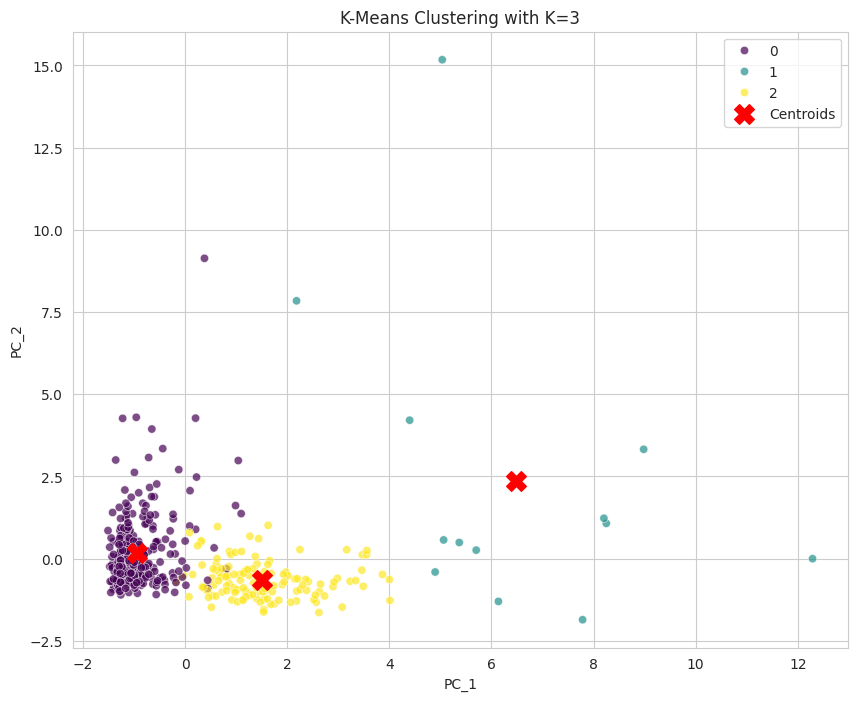

K-Means clustering with K=3 performed. Centroids and cluster assignments are visualized.


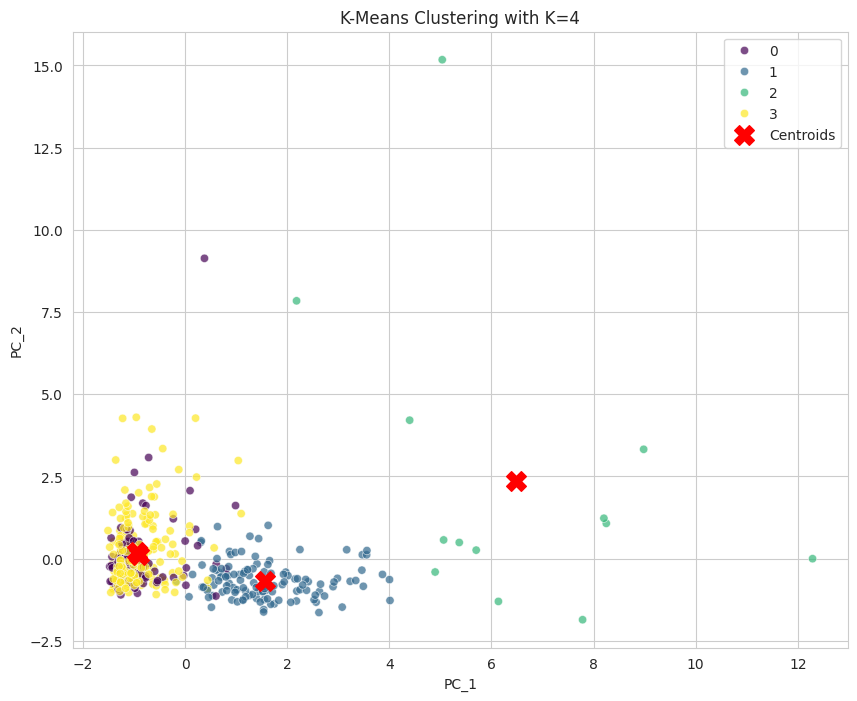

K-Means clustering with K=4 performed. Centroids and cluster assignments are visualized.


In [ ]:
ks = [2, 3, 4]

for k in ks:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans_labels = kmeans.fit_predict(data_for_clustering)
    centroids = kmeans.cluster_centers_

    plt.figure(figsize=(10, 8))
    if data_for_clustering.shape[1] >= 2:
        sns.scatterplot(x=data_for_clustering.iloc[:, 0], y=data_for_clustering.iloc[:, 1], hue=kmeans_labels, palette='viridis', legend='full', alpha=0.7)
        plt.scatter(centroids[:, 0], centroids[:, 1], marker='X', s=200, color='red', label='Centroids')
        plt.xlabel(data_for_clustering.columns[0])
        plt.ylabel(data_for_clustering.columns[1])
    else:
        # For 1-D data, plot points along a line with their cluster assignments
        sns.scatterplot(x=data_for_clustering.iloc[:, 0], y=np.zeros(len(data_for_clustering)), hue=kmeans_labels, palette='viridis', legend='full', alpha=0.7)
        plt.scatter(centroids[:, 0], np.zeros(k), marker='X', s=200, color='red', label='Centroids')
        plt.xlabel(data_for_clustering.columns[0])
        plt.ylabel('Dimension 2 (Arbitrary for 1D Data)')
        plt.yticks([]) # Hide y-ticks for 1D visualization

    plt.title(f'K-Means Clustering with K={k}')
    plt.legend()
    plt.grid(True)
    plt.show()

    print(f"K-Means clustering with K={k} performed. Centroids and cluster assignments are visualized.")

### 16. Spectral Clustering

Spectral clustering is a modern clustering algorithm that makes use of the spectrum (eigenvalues) of the similarity matrix of the data to perform dimensionality reduction before clustering in fewer dimensions. It is particularly effective when clusters are not compact or convex. We will apply it with K=2, 3, and 4.

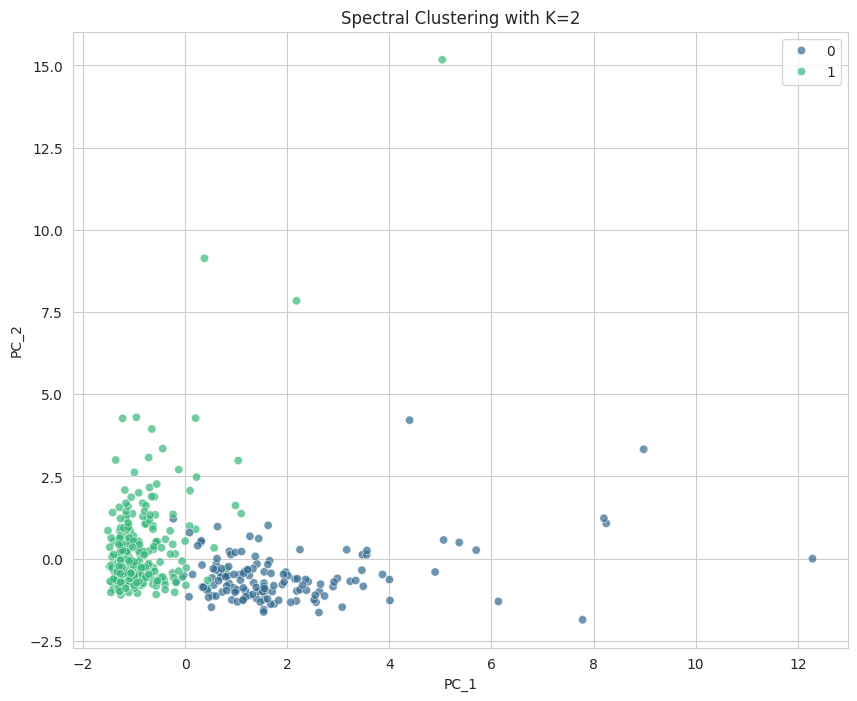

Spectral clustering with K=2 performed. Cluster assignments are visualized and can be compared with K-Means results.


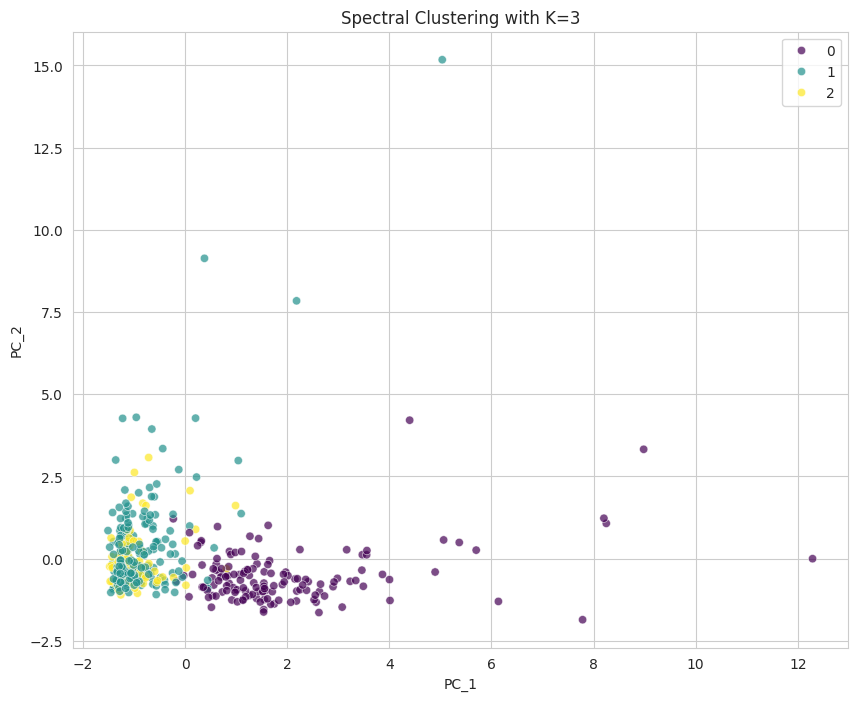

Spectral clustering with K=3 performed. Cluster assignments are visualized and can be compared with K-Means results.


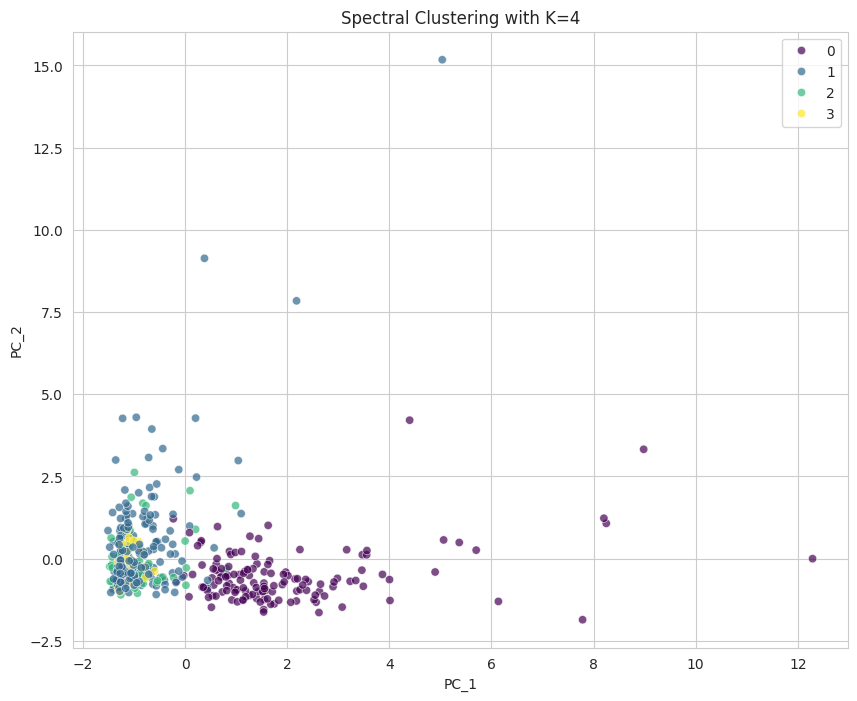

Spectral clustering with K=4 performed. Cluster assignments are visualized and can be compared with K-Means results.


In [ ]:
from sklearn.cluster import SpectralClustering

for k in ks:
    # SpectralClustering requires n_components to be set, it's often best to use an affinity matrix
    # For simplicity, we'll use 'nearest_neighbors' affinity and apply directly.
    spectral = SpectralClustering(n_clusters=k, assign_labels='kmeans', random_state=42, affinity='nearest_neighbors')
    spectral_labels = spectral.fit_predict(data_for_clustering)

    plt.figure(figsize=(10, 8))
    if data_for_clustering.shape[1] >= 2:
        sns.scatterplot(x=data_for_clustering.iloc[:, 0], y=data_for_clustering.iloc[:, 1], hue=spectral_labels, palette='viridis', legend='full', alpha=0.7)
        plt.xlabel(data_for_clustering.columns[0])
        plt.ylabel(data_for_clustering.columns[1])
    else:
        sns.scatterplot(x=data_for_clustering.iloc[:, 0], y=np.zeros(len(data_for_clustering)), hue=spectral_labels, palette='viridis', legend='full', alpha=0.7)
        plt.xlabel(data_for_clustering.columns[0])
        plt.ylabel('Dimension 2 (Arbitrary for 1D Data)')
        plt.yticks([])

    plt.title(f'Spectral Clustering with K={k}')
    plt.legend()
    plt.grid(True)
    plt.show()

    print(f"Spectral clustering with K={k} performed. Cluster assignments are visualized and can be compared with K-Means results.")

### 17. Gaussian Mixture Model (GMM)

Gaussian Mixture Models (GMMs) are a probabilistic model that assumes all the data points are generated from a mixture of a finite number of Gaussian distributions with unknown parameters. Unlike K-Means, GMMs provide probabilities of each data point belonging to a cluster, rather than hard assignments. We will evaluate clustering results for K=2, 3, and 4.

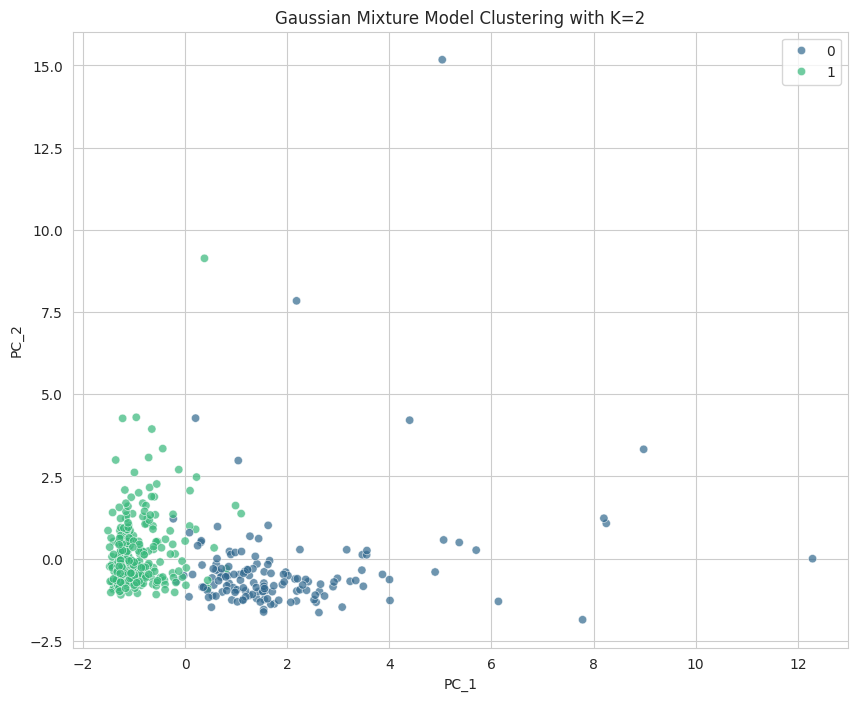

Gaussian Mixture Model clustering with K=2 performed. Cluster assignments are visualized and can be compared with K-Means and Spectral Clustering results.


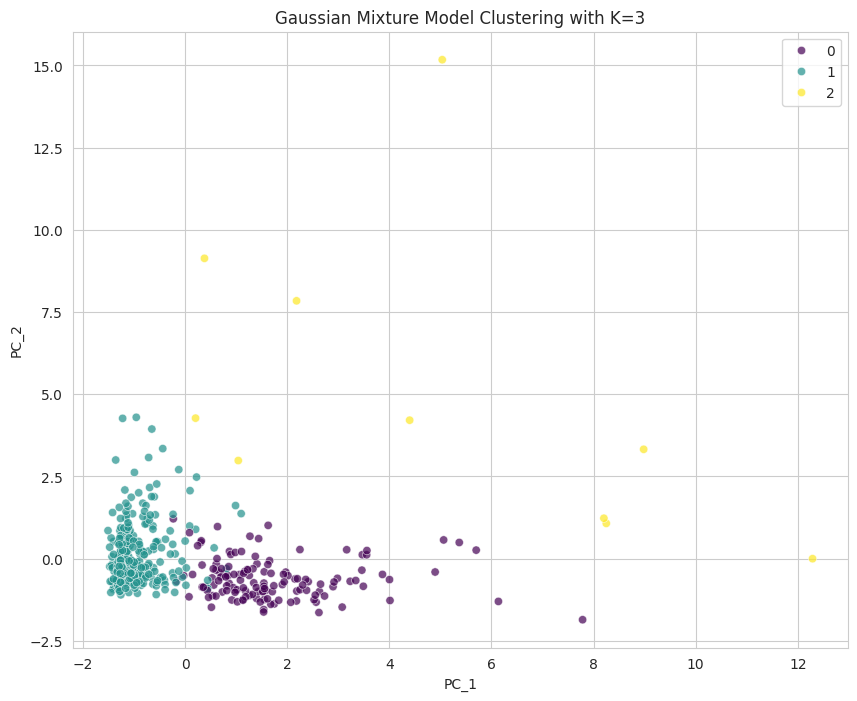

Gaussian Mixture Model clustering with K=3 performed. Cluster assignments are visualized and can be compared with K-Means and Spectral Clustering results.


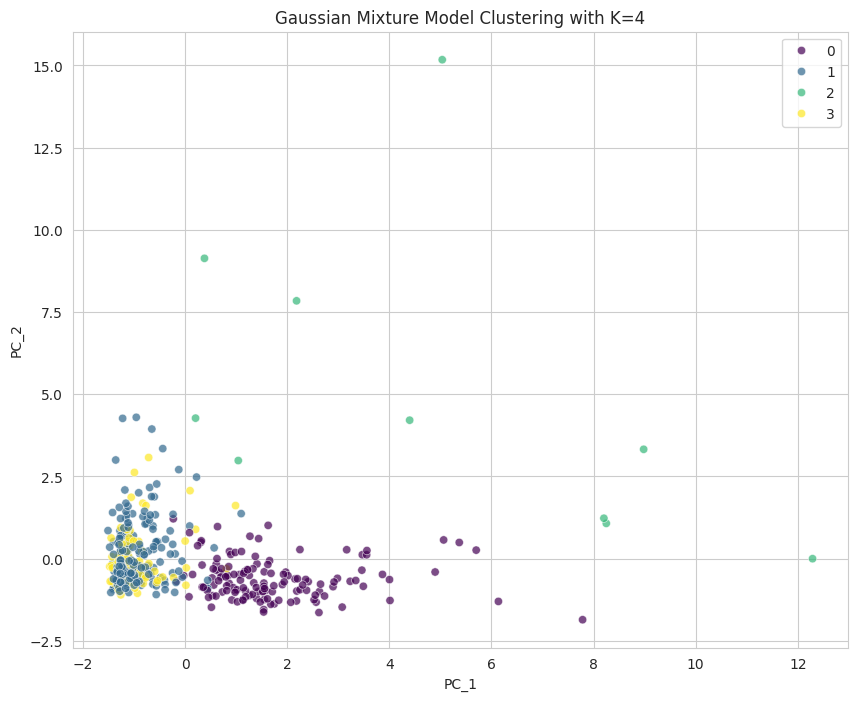

Gaussian Mixture Model clustering with K=4 performed. Cluster assignments are visualized and can be compared with K-Means and Spectral Clustering results.


In [ ]:
from sklearn.mixture import GaussianMixture

for k in ks:
    gmm = GaussianMixture(n_components=k, random_state=42)
    gmm.fit(data_for_clustering)
    gmm_labels = gmm.predict(data_for_clustering)

    plt.figure(figsize=(10, 8))
    if data_for_clustering.shape[1] >= 2:
        sns.scatterplot(x=data_for_clustering.iloc[:, 0], y=data_for_clustering.iloc[:, 1], hue=gmm_labels, palette='viridis', legend='full', alpha=0.7)
        # Optionally plot component means
        # plt.scatter(gmm.means_[:, 0], gmm.means_[:, 1], marker='X', s=200, color='red', label='Component Means')
        plt.xlabel(data_for_clustering.columns[0])
        plt.ylabel(data_for_clustering.columns[1])
    else:
        sns.scatterplot(x=data_for_clustering.iloc[:, 0], y=np.zeros(len(data_for_clustering)), hue=gmm_labels, palette='viridis', legend='full', alpha=0.7)
        plt.xlabel(data_for_clustering.columns[0])
        plt.ylabel('Dimension 2 (Arbitrary for 1D Data)')
        plt.yticks([])

    plt.title(f'Gaussian Mixture Model Clustering with K={k}')
    plt.legend()
    plt.grid(True)
    plt.show()

    print(f"Gaussian Mixture Model clustering with K={k} performed. Cluster assignments are visualized and can be compared with K-Means and Spectral Clustering results.")

### 18. Clustering Evaluation with Internal Validation Metrics

Internal validation metrics are used to evaluate the quality of a clustering structure without reference to external information. We will calculate the Silhouette Score, Davies-Bouldin Index (DBI), and Calinski-Harabasz Index for each clustering algorithm and for K=2, 3, and 4. A higher Silhouette Score and Calinski-Harabasz Index indicate better-defined clusters, while a lower Davies-Bouldin Index indicates better separation.

In [ ]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.cluster import KMeans, SpectralClustering
from sklearn.mixture import GaussianMixture

# Ensure data_for_clustering and ks are defined from previous steps
# data_for_clustering = df_pca if df_pca.shape[1] >= 2 else df_scaled
# ks = [2, 3, 4]

print("--- Clustering Evaluation Metrics ---")

results = []

for k in ks:
    print(f"\nEvaluating for K = {k}")

    # K-Means
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans_labels = kmeans.fit_predict(data_for_clustering)
    if len(set(kmeans_labels)) > 1:
        sil_kmeans = silhouette_score(data_for_clustering, kmeans_labels)
        dbi_kmeans = davies_bouldin_score(data_for_clustering, kmeans_labels)
        chs_kmeans = calinski_harabasz_score(data_for_clustering, kmeans_labels)
        print(f"K-Means: Silhouette Score = {sil_kmeans:.3f}, DBI = {dbi_kmeans:.3f}, CHS = {chs_kmeans:.3f}")
        results.append({'Algorithm': 'K-Means', 'K': k, 'Silhouette': sil_kmeans, 'DBI': dbi_kmeans, 'CHS': chs_kmeans})
    else:
        print(f"K-Means: Only 1 cluster formed, cannot compute metrics.")

    # Spectral Clustering
    try:
        spectral = SpectralClustering(n_clusters=k, assign_labels='kmeans', random_state=42, affinity='nearest_neighbors')
        spectral_labels = spectral.fit_predict(data_for_clustering)
        if len(set(spectral_labels)) > 1:
            sil_spectral = silhouette_score(data_for_clustering, spectral_labels)
            dbi_spectral = davies_bouldin_score(data_for_clustering, spectral_labels)
            chs_spectral = calinski_harabasz_score(data_for_clustering, spectral_labels)
            print(f"Spectral Clustering: Silhouette Score = {sil_spectral:.3f}, DBI = {dbi_spectral:.3f}, CHS = {chs_spectral:.3f}")
            results.append({'Algorithm': 'Spectral', 'K': k, 'Silhouette': sil_spectral, 'DBI': dbi_spectral, 'CHS': chs_spectral})
        else:
            print(f"Spectral Clustering: Only 1 cluster formed, cannot compute metrics.")
    except ValueError as e:
        print(f"Spectral Clustering for K={k} encountered an error: {e}. Skipping metrics.")

    # Gaussian Mixture Model
    gmm = GaussianMixture(n_components=k, random_state=42)
    gmm.fit(data_for_clustering)
    gmm_labels = gmm.predict(data_for_clustering)
    if len(set(gmm_labels)) > 1:
        sil_gmm = silhouette_score(data_for_clustering, gmm_labels)
        dbi_gmm = davies_bouldin_score(data_for_clustering, gmm_labels)
        chs_gmm = calinski_harabasz_score(data_for_clustering, gmm_labels)
        print(f"GMM: Silhouette Score = {sil_gmm:.3f}, DBI = {dbi_gmm:.3f}, CHS = {chs_gmm:.3f}")
        results.append({'Algorithm': 'GMM', 'K': k, 'Silhouette': sil_gmm, 'DBI': dbi_gmm, 'CHS': chs_gmm})
    else:
        print(f"GMM: Only 1 cluster formed, cannot compute metrics.")

# Display results in a DataFrame for easier comparison
results_df = pd.DataFrame(results)
display(results_df)

print("Note: Dunn Index requires a custom implementation or specific library. The provided metrics are commonly used and available in scikit-learn.")

--- Clustering Evaluation Metrics ---

Evaluating for K = 2
K-Means: Silhouette Score = 0.386, DBI = 1.208, CHS = 164.642
Spectral Clustering: Silhouette Score = 0.377, DBI = 1.211, CHS = 161.480
GMM: Silhouette Score = 0.385, DBI = 1.259, CHS = 161.733

Evaluating for K = 3
K-Means: Silhouette Score = 0.371, DBI = 1.111, CHS = 149.609
Spectral Clustering: Silhouette Score = 0.317, DBI = 1.204, CHS = 120.761
GMM: Silhouette Score = 0.385, DBI = 1.245, CHS = 141.229

Evaluating for K = 4
K-Means: Silhouette Score = 0.368, DBI = 1.171, CHS = 142.274
Spectral Clustering: Silhouette Score = 0.139, DBI = 1.500, CHS = 83.036
GMM: Silhouette Score = 0.352, DBI = 1.229, CHS = 133.296


,Algorithm,K,Silhouette,DBI,CHS
0,K-Means,2,0.385537,1.208069,164.641526
1,Spectral,2,0.376782,1.211081,161.480453
2,GMM,2,0.384508,1.258796,161.733025
3,K-Means,3,0.371045,1.111323,149.608796
4,Spectral,3,0.316999,1.203567,120.760791
5,GMM,3,0.384791,1.245287,141.228662
6,K-Means,4,0.367665,1.171417,142.273910
7,Spectral,4,0.139247,1.500472,83.036329
8,GMM,4,0.351845,1.229240,133.296217


Note: Dunn Index requires a custom implementation or specific library. The provided metrics are commonly used and available in scikit-learn.


### 19. Results Analysis and Cluster Profiling

This section provides an analysis of the clustering results, including a comparison between algorithms, the impact of K, interpretation of evaluation metrics, and cluster profiling to understand the characteristics of each group.

In [ ]:
# For cluster profiling, we'll choose K=3 as an example, as it often provides a good balance.
# We'll use the original (unscaled) DataFrame to make the cluster profiles interpretable.

chosen_k = 3 # You can change this based on Elbow method or metric evaluation

print(f"\n--- Cluster Profiling for K = {chosen_k} ---")

# K-Means Cluster Profiling
kmeans_model = KMeans(n_clusters=chosen_k, init='k-means++', random_state=42, n_init=10)
kmeans_labels_profile = kmeans_model.fit_predict(data_for_clustering)
df_kmeans_profile = df.copy() # Use original df for interpretable values
df_kmeans_profile['Cluster'] = kmeans_labels_profile
print(f"\nK-Means (K={chosen_k}) Cluster Profiles:")
display(df_kmeans_profile.groupby('Cluster').mean())

# Spectral Clustering Cluster Profiling
spectral_model = SpectralClustering(n_clusters=chosen_k, assign_labels='kmeans', random_state=42, affinity='nearest_neighbors')
spectral_labels_profile = spectral_model.fit_predict(data_for_clustering)
df_spectral_profile = df.copy()
df_spectral_profile['Cluster'] = spectral_labels_profile
print(f"\nSpectral Clustering (K={chosen_k}) Cluster Profiles:")
display(df_spectral_profile.groupby('Cluster').mean())

# Gaussian Mixture Model Cluster Profiling
gmm_model = GaussianMixture(n_components=chosen_k, random_state=42)
gmm_model.fit(data_for_clustering)
gmm_labels_profile = gmm_model.predict(data_for_clustering)
df_gmm_profile = df.copy()
df_gmm_profile['Cluster'] = gmm_labels_profile
print(f"\nGaussian Mixture Model (K={chosen_k}) Cluster Profiles:")
display(df_gmm_profile.groupby('Cluster').mean())

print("\n--- Overall Analysis ---")
print("Based on the evaluation metrics (Silhouette, DBI, CHS), we can compare how well each algorithm performed at different K values. Higher Silhouette and CHS, and lower DBI, generally indicate better clustering.")
print("The cluster profiles (average feature values per cluster) help in understanding the characteristics of customers within each group. For instance, one cluster might represent 'small fresh produce buyers' while another might be 'large frozen and detergents buyers'.")
print("The visualizations from previous steps (PCA, t-SNE, and algorithm-specific plots) also provide qualitative insights into the cluster structures and separations.")


--- Cluster Profiling for K = 3 ---

K-Means (K=3) Cluster Profiles:


,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
Cluster,,,,,,,,
0,1.003367,2.505051,13075.898990,3218.737374,3855.696970,3620.400673,776.875421,1242.249158
1,1.846154,2.615385,25770.769231,35160.384615,41977.384615,6844.538462,19867.384615,7880.307692
2,2.000000,2.623077,8165.915385,8748.515385,13905.492308,1441.630769,5991.146154,1535.007692



Spectral Clustering (K=3) Cluster Profiles:


,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
Cluster,,,,,,,,
0,2.0,2.612676,8904.323944,10716.500000,16322.852113,1652.612676,7269.507042,1753.436620
1,1.0,2.985981,13869.266355,3525.056075,3939.967290,4021.705607,783.065421,1531.000000
2,1.0,1.297619,12472.547619,3264.904762,4018.619048,3051.595238,809.654762,1122.869048



Gaussian Mixture Model (K=3) Cluster Profiles:


,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
Cluster,,,,,,,,
0,2.0,2.598540,8164.897810,9291.948905,15005.569343,1580.058394,6687.328467,1606.832117
1,1.0,2.505119,12875.242321,3180.757679,3752.948805,3382.750853,762.375427,1129.795222
2,1.5,2.900000,38909.400000,34539.800000,34318.500000,14403.600000,12831.700000,11977.700000



--- Overall Analysis ---
Based on the evaluation metrics (Silhouette, DBI, CHS), we can compare how well each algorithm performed at different K values. Higher Silhouette and CHS, and lower DBI, generally indicate better clustering.
The cluster profiles (average feature values per cluster) help in understanding the characteristics of customers within each group. For instance, one cluster might represent 'small fresh produce buyers' while another might be 'large frozen and detergents buyers'.
The visualizations from previous steps (PCA, t-SNE, and algorithm-specific plots) also provide qualitative insights into the cluster structures and separations.
